# Phase 4 vs Phase 6 — Neuron Comparison Analysis

**Phase 4**: geo + math (2 domains)  
**Phase 6**: geo + math + business_ethics + philosophy (4 domains)

This notebook compares the universal money, reward, and master core neuron sets across both phases, with full layer-level breakdowns and visualizations.

## 0. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
PHASE4_DIR = "/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction"
PHASE6_DIR = "/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase6"  # adjust if needed

FILES = {
    "money":  "universal_money_neurons.csv",
    "reward": "universal_reward_neurons.csv",
    "core":   "master_incentive_core.csv",
}

NUM_LAYERS = 28
SUPPRESSION_LAYERS = list(range(8, 15))  # L8–L14 known suppression circuit

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = {
    'p4':        '#4C72B0',
    'p6':        '#DD8452',
    'shared':    '#55A868',
    'only_p4':   '#C44E52',
    'only_p6':   '#8172B2',
    'circuit':   '#CCB974',
}
print('Configuration loaded.')

Configuration loaded.


## 1. Load & Parse All Neuron Sets

In [2]:
def load_neuron_df(path):
    df = pd.read_csv(path)
    return df

def to_set(df):
    return set(zip(df['layer'].tolist(), df['neuron'].tolist()))

# Load all six CSVs
data = {}
for key, fname in FILES.items():
    p4_path = os.path.join(PHASE4_DIR, fname)
    p6_path = os.path.join(PHASE6_DIR, fname)
    p4_df = load_neuron_df(p4_path)
    p6_df = load_neuron_df(p6_path)
    p4_set = to_set(p4_df)
    p6_set = to_set(p6_df)
    data[key] = {
        'p4_df': p4_df, 'p6_df': p6_df,
        'p4': p4_set, 'p6': p6_set,
        'shared':  p4_set & p6_set,
        'only_p4': p4_set - p6_set,
        'only_p6': p6_set - p4_set,
    }

# Summary table
rows = []
for key in FILES:
    d = data[key]
    rows.append({
        'Neuron set': key,
        'Phase4': len(d['p4']),
        'Phase6': len(d['p6']),
        'Shared': len(d['shared']),
        'Only P4': len(d['only_p4']),
        'Only P6': len(d['only_p6']),
        'Retention % (shared/P4)': f"{len(d['shared'])/len(d['p4'])*100:.1f}%",
        'Coverage % (shared/P6)':  f"{len(d['shared'])/len(d['p6'])*100:.1f}%",
    })

summary_df = pd.DataFrame(rows).set_index('Neuron set')
display(summary_df)

,Phase4,Phase6,Shared,Only P4,Only P6,Retention % (shared/P4),Coverage % (shared/P6)
Neuron set,,,,,,,
money,5467,1972,1972,3495,0,36.1%,100.0%
reward,5558,1896,1896,3662,0,34.1%,100.0%
core,3528,1224,1224,2304,0,34.7%,100.0%


## 2. High-Level Overlap — Venn-Style Bar Charts

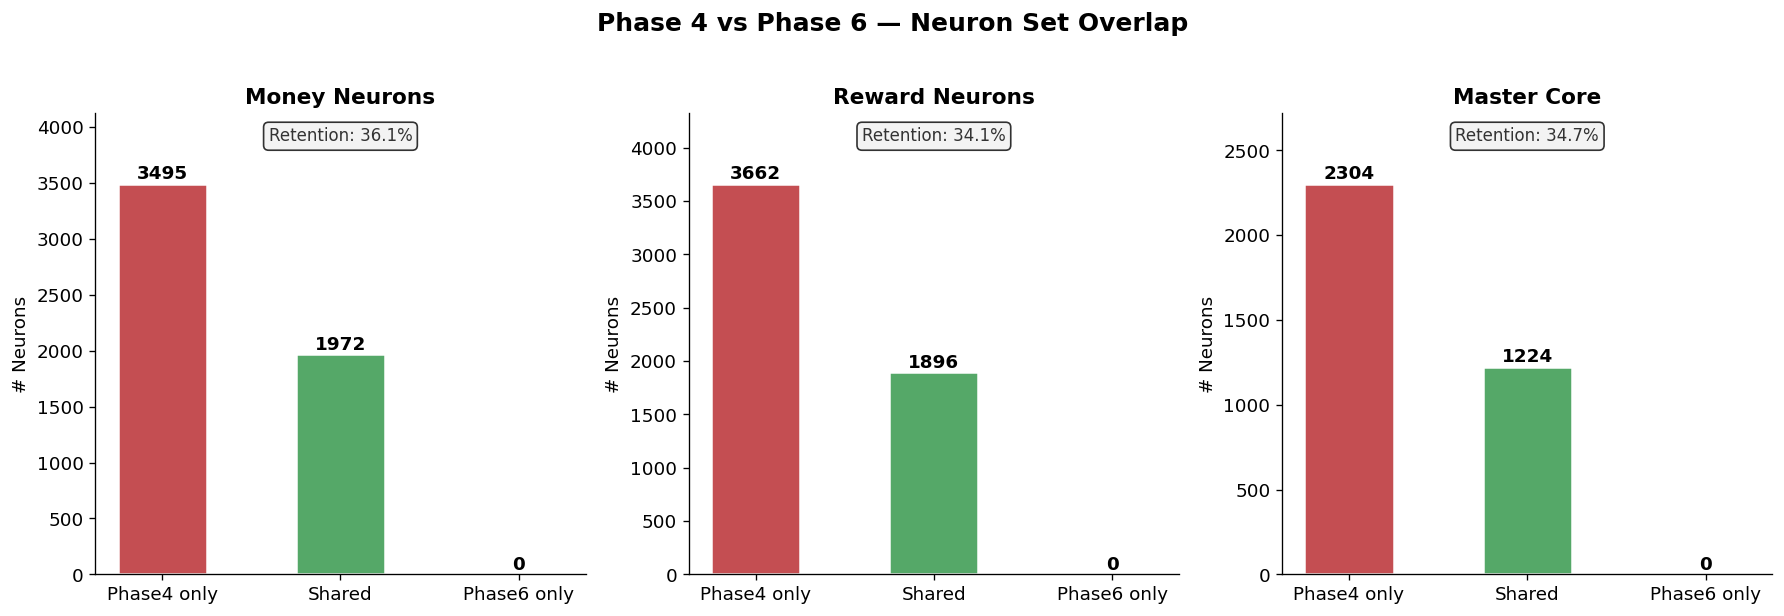

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = {'money': 'Money Neurons', 'reward': 'Reward Neurons', 'core': 'Master Core'}

for ax, (key, title) in zip(axes, titles.items()):
    d = data[key]
    categories = ['Phase4 only', 'Shared', 'Phase6 only']
    counts     = [len(d['only_p4']), len(d['shared']), len(d['only_p6'])]
    colors     = [COLORS['only_p4'], COLORS['shared'], COLORS['only_p6']]
    bars = ax.bar(categories, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(cnt), ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('# Neurons')
    ax.set_ylim(0, max(counts) * 1.18)

    # Retention annotation
    ret = len(d['shared']) / len(d['p4']) * 100
    ax.text(0.5, 0.97, f"Retention: {ret:.1f}%", transform=ax.transAxes,
            ha='center', va='top', fontsize=10, color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle('Phase 4 vs Phase 6 — Neuron Set Overlap', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_overlap_bars.png', bbox_inches='tight')
plt.show()

## 3. Layer Distribution — Phase 4 vs Phase 6 vs Shared

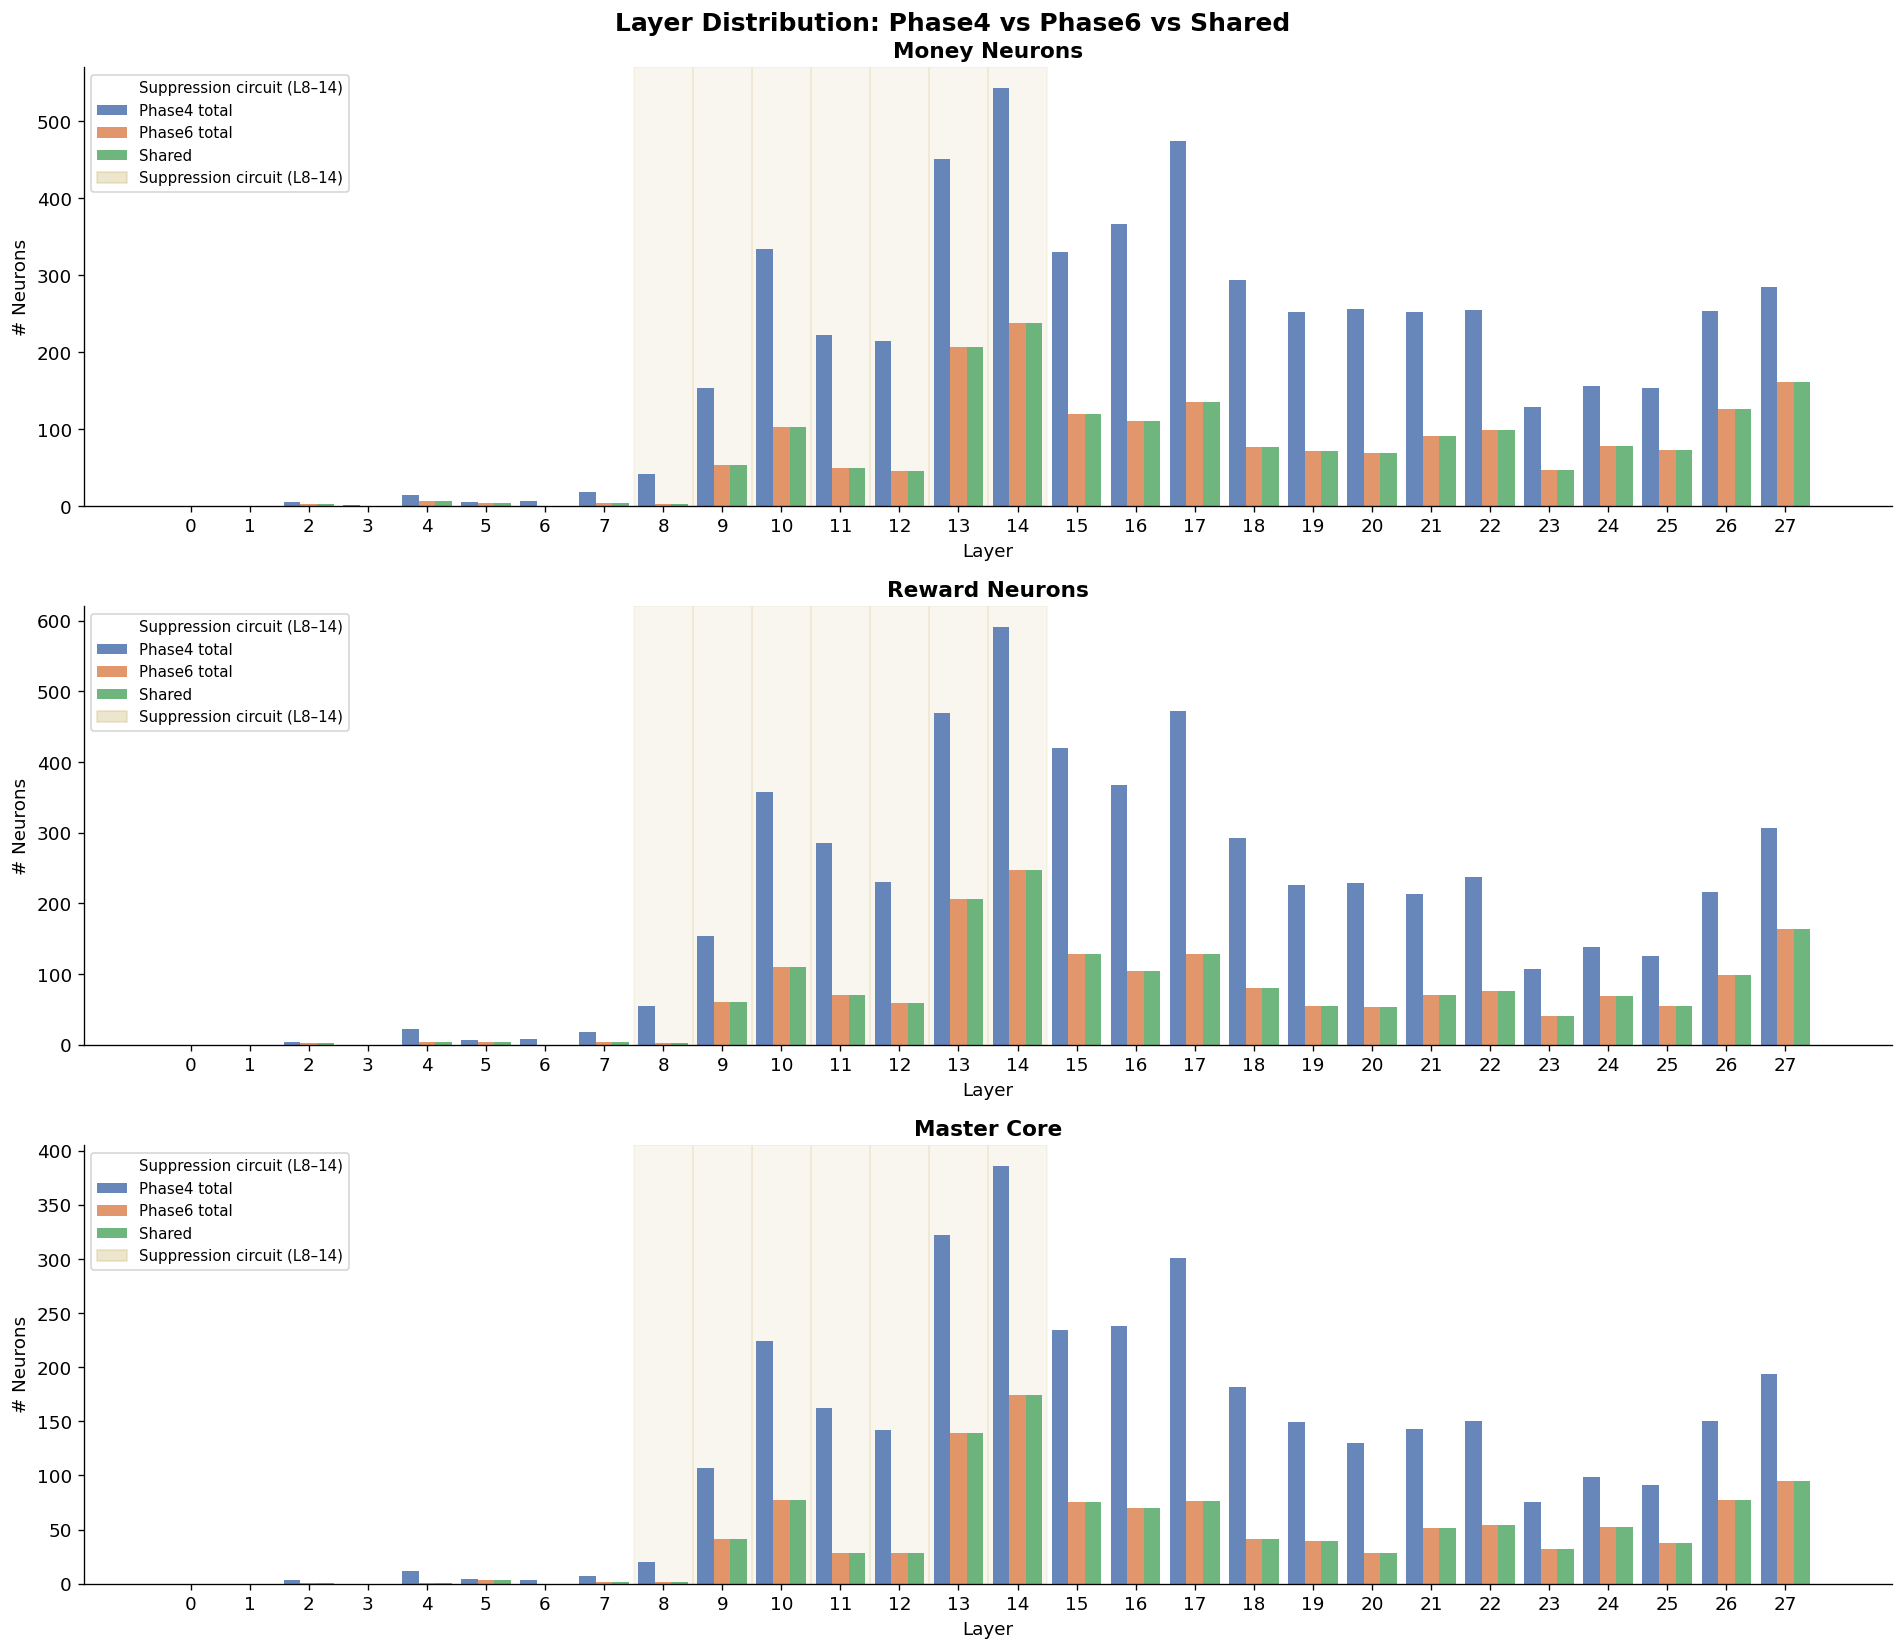

In [5]:
def layer_counts(neuron_set, num_layers=NUM_LAYERS):
    counts = np.zeros(num_layers, dtype=int)
    for layer, _ in neuron_set:
        counts[layer] += 1
    return counts

layers = np.arange(NUM_LAYERS)
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, (key, title) in zip(axes, titles.items()):
    d = data[key]
    c_p4     = layer_counts(d['p4'])
    c_p6     = layer_counts(d['p6'])
    c_shared = layer_counts(d['shared'])
    c_only_p4 = layer_counts(d['only_p4'])
    c_only_p6 = layer_counts(d['only_p6'])

    w = 0.28
    ax.bar(layers - w, c_p4,     width=w, label='Phase4 total', color=COLORS['p4'],     alpha=0.85)
    ax.bar(layers,     c_p6,     width=w, label='Phase6 total', color=COLORS['p6'],     alpha=0.85)
    ax.bar(layers + w, c_shared, width=w, label='Shared',       color=COLORS['shared'], alpha=0.85)

    # Shade suppression circuit
    for l in SUPPRESSION_LAYERS:
        ax.axvspan(l - 0.5, l + 0.5, color=COLORS['circuit'], alpha=0.12, zorder=0)
    ax.axvspan(SUPPRESSION_LAYERS[0] - 0.5, SUPPRESSION_LAYERS[-1] + 0.5,
               color=COLORS['circuit'], alpha=0, label='Suppression circuit (L8–14)')
    # Invisible patch for legend
    from matplotlib.patches import Patch
    circuit_patch = Patch(color=COLORS['circuit'], alpha=0.35, label='Suppression circuit (L8–14)')

    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Layer')
    ax.set_ylabel('# Neurons')
    ax.set_xticks(layers)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [circuit_patch], labels + ['Suppression circuit (L8–14)'],
              loc='upper left', fontsize=9)

plt.suptitle('Layer Distribution: Phase4 vs Phase6 vs Shared', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_layer_distribution.png', bbox_inches='tight')
plt.show()

## 4. Phase4-Only vs Phase6-Only Neurons per Layer

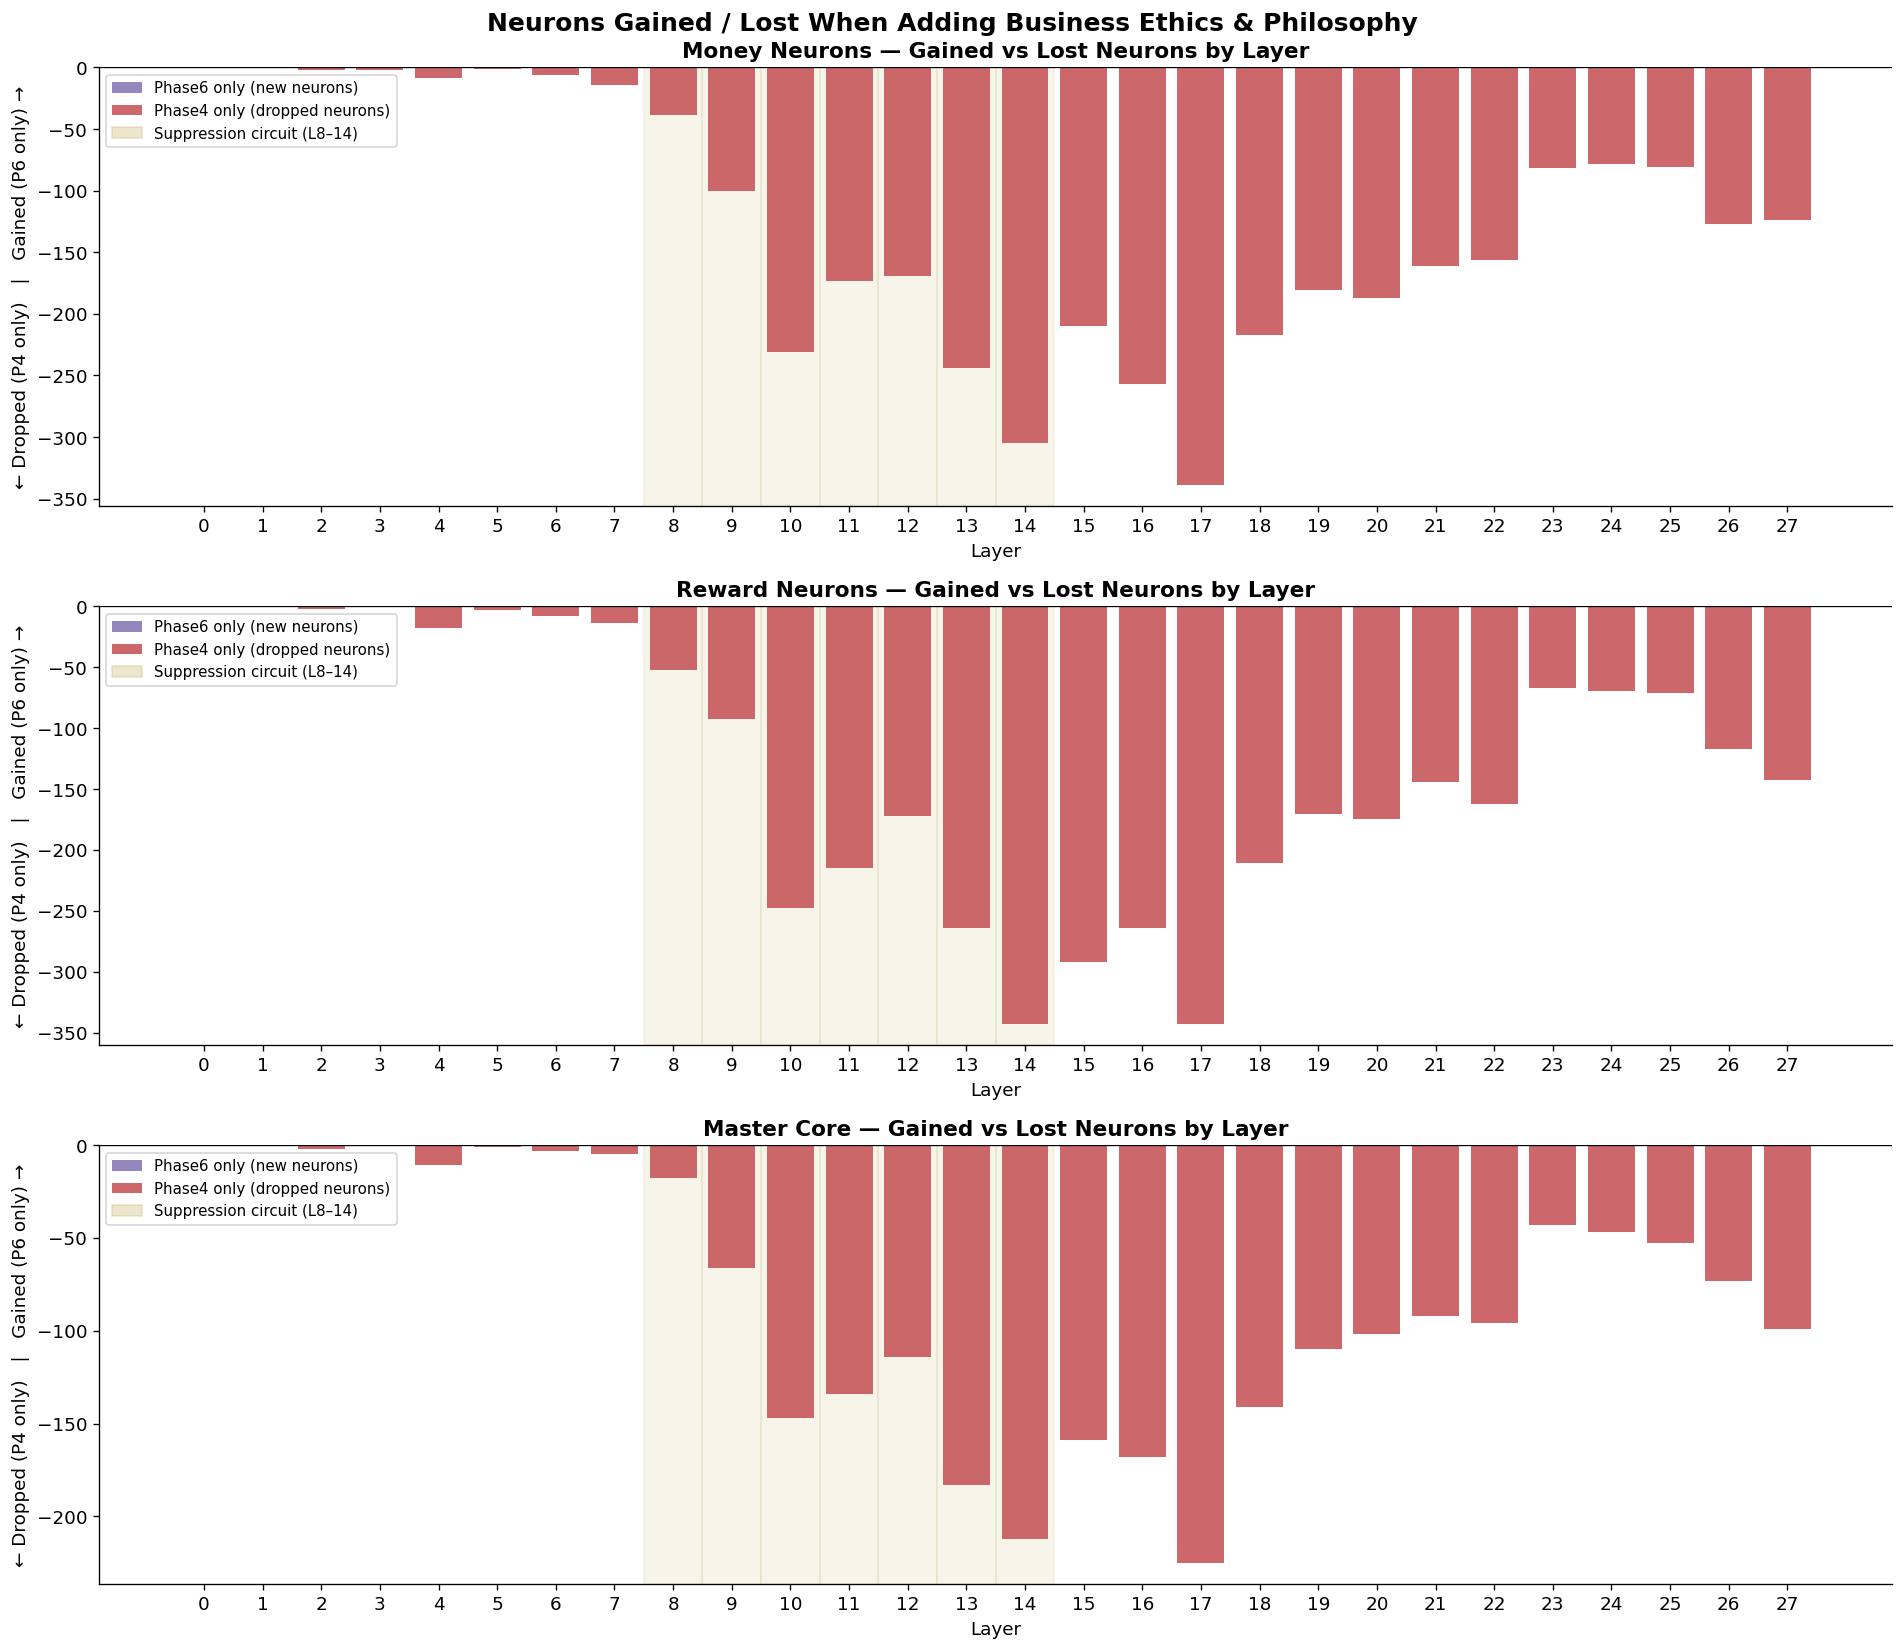

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, (key, title) in zip(axes, titles.items()):
    d = data[key]
    c_only_p4 = layer_counts(d['only_p4'])
    c_only_p6 = layer_counts(d['only_p6'])

    # Diverging bar: P4-only goes down, P6-only goes up
    ax.bar(layers,  c_only_p6,  color=COLORS['only_p6'], alpha=0.85, label='Phase6 only (new neurons)')
    ax.bar(layers, -c_only_p4, color=COLORS['only_p4'], alpha=0.85, label='Phase4 only (dropped neurons)')
    ax.axhline(0, color='black', linewidth=0.8)

    # Suppression circuit shading
    for l in SUPPRESSION_LAYERS:
        ax.axvspan(l - 0.5, l + 0.5, color=COLORS['circuit'], alpha=0.15, zorder=0)

    ax.set_title(f"{title} — Gained vs Lost Neurons by Layer", fontweight='bold', fontsize=13)
    ax.set_xlabel('Layer')
    ax.set_ylabel('← Dropped (P4 only)   |   Gained (P6 only) →')
    ax.set_xticks(layers)
    ax.legend(fontsize=9)

    from matplotlib.patches import Patch
    circuit_patch = Patch(color=COLORS['circuit'], alpha=0.35, label='Suppression circuit (L8–14)')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [circuit_patch], labels + ['Suppression circuit (L8–14)'], fontsize=9)

plt.suptitle('Neurons Gained / Lost When Adding Business Ethics & Philosophy', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_gained_lost.png', bbox_inches='tight')
plt.show()

## 5. Suppression Circuit (L8–L14) Deep Dive

In [7]:
print("=" * 60)
print("SUPPRESSION CIRCUIT (L8–L14) ANALYSIS")
print("=" * 60)

circuit_rows = []
for key in FILES:
    d = data[key]
    p4_c  = {(l,n) for l,n in d['p4']     if l in SUPPRESSION_LAYERS}
    p6_c  = {(l,n) for l,n in d['p6']     if l in SUPPRESSION_LAYERS}
    sh_c  = {(l,n) for l,n in d['shared'] if l in SUPPRESSION_LAYERS}
    circuit_rows.append({
        'Set': key,
        'P4 circuit': len(p4_c),
        'P6 circuit': len(p6_c),
        'Shared circuit': len(sh_c),
        'P4 circuit retention': f"{len(sh_c)/max(len(p4_c),1)*100:.1f}%",
        'P4 circuit %': f"{len(p4_c)/max(len(d['p4']),1)*100:.1f}%",
        'P6 circuit %': f"{len(p6_c)/max(len(d['p6']),1)*100:.1f}%",
    })

circuit_df = pd.DataFrame(circuit_rows).set_index('Set')
display(circuit_df)

# Per-layer breakdown within suppression circuit for master core
print("\nMaster Core — Per-layer count within suppression circuit:")
d = data['core']
header = f"{'Layer':<8} {'P4':>6} {'P6':>6} {'Shared':>8} {'P4-only':>8} {'P6-only':>8}"
print(header)
print('-' * len(header))
for l in SUPPRESSION_LAYERS:
    p4_l  = sum(1 for ll,_ in d['p4']      if ll == l)
    p6_l  = sum(1 for ll,_ in d['p6']      if ll == l)
    sh_l  = sum(1 for ll,_ in d['shared']  if ll == l)
    op4_l = sum(1 for ll,_ in d['only_p4'] if ll == l)
    op6_l = sum(1 for ll,_ in d['only_p6'] if ll == l)
    print(f"  L{l:<5} {p4_l:>6} {p6_l:>6} {sh_l:>8} {op4_l:>8} {op6_l:>8}")

SUPPRESSION CIRCUIT (L8–L14) ANALYSIS


,P4 circuit,P6 circuit,Shared circuit,P4 circuit retention,P4 circuit %,P6 circuit %
Set,,,,,,
money,1959,698,698,35.6%,35.8%,35.4%
reward,2144,757,757,35.3%,38.6%,39.9%
core,1363,489,489,35.9%,38.6%,40.0%



Master Core — Per-layer count within suppression circuit:
Layer        P4     P6   Shared  P4-only  P6-only
-------------------------------------------------
  L8         20      2        2       18        0
  L9        107     41       41       66        0
  L10       224     77       77      147        0
  L11       162     28       28      134        0
  L12       142     28       28      114        0
  L13       322    139      139      183        0
  L14       386    174      174      212        0


## 6. Heatmap — Shared Neuron Density per Layer (Master Core)

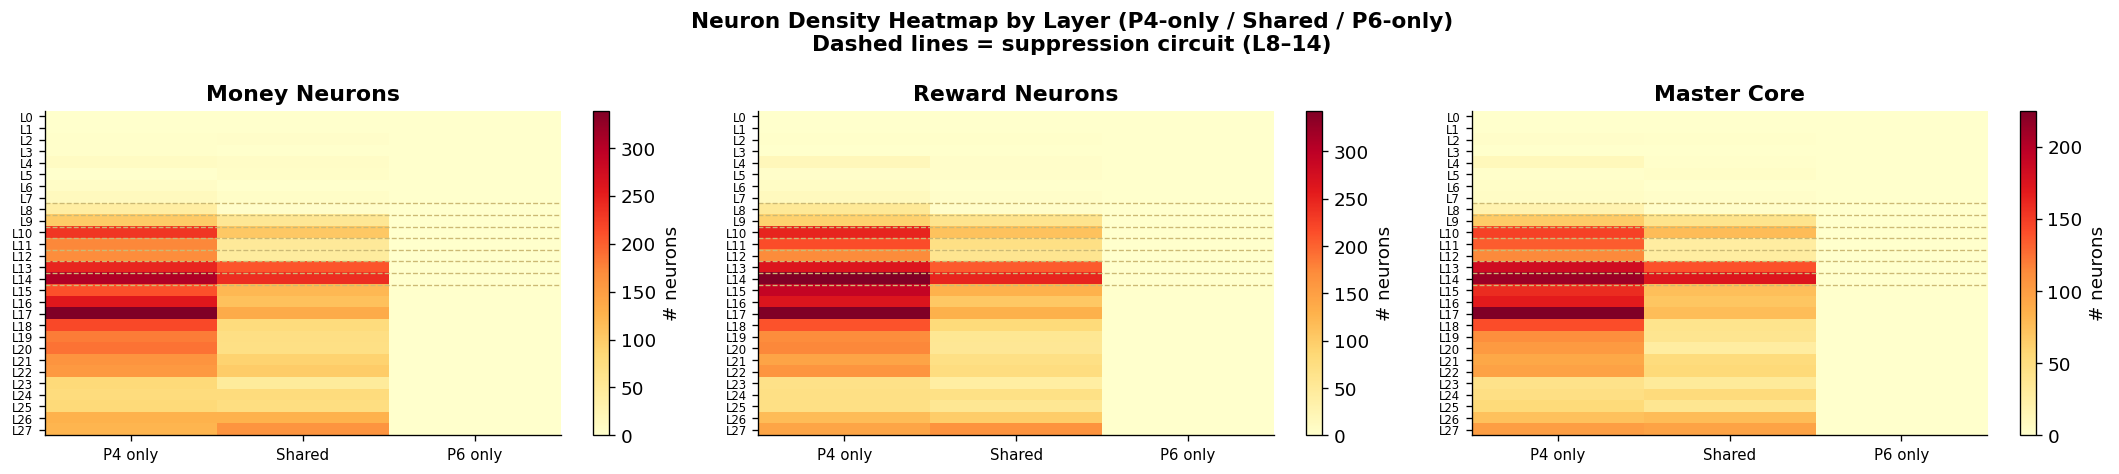

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (key, title) in zip(axes, titles.items()):
    d = data[key]
    # Build matrix: rows = layers, cols = [P4-only, Shared, P6-only]
    mat = np.zeros((NUM_LAYERS, 3))
    for l, _ in d['only_p4']: mat[l, 0] += 1
    for l, _ in d['shared']:  mat[l, 1] += 1
    for l, _ in d['only_p6']: mat[l, 2] += 1

    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['P4 only', 'Shared', 'P6 only'], fontsize=9)
    ax.set_yticks(range(NUM_LAYERS))
    ax.set_yticklabels([f'L{i}' for i in range(NUM_LAYERS)], fontsize=7)
    ax.set_title(title, fontweight='bold')

    # Mark suppression circuit
    for l in SUPPRESSION_LAYERS:
        ax.axhline(l - 0.5, color=COLORS['circuit'], linewidth=0.8, linestyle='--')
    ax.axhline(SUPPRESSION_LAYERS[-1] + 0.5, color=COLORS['circuit'], linewidth=0.8, linestyle='--')

    plt.colorbar(im, ax=ax, label='# neurons')

plt.suptitle('Neuron Density Heatmap by Layer (P4-only / Shared / P6-only)\n'
             'Dashed lines = suppression circuit (L8–14)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Cross-Set Overlap — Money ∩ Reward ∩ Core per Phase

CROSS-SET OVERLAP

Phase 4:
  Money ∩ Reward          :  3528
  Money ∩ Reward == Core? : True  (Core has 3528, intersection has 3528)
  Money only (not reward) :  1939
  Reward only (not money) :  2030

Phase 6:
  Money ∩ Reward          :  1224
  Money ∩ Reward == Core? : True  (Core has 1224, intersection has 1224)
  Money only (not reward) :   748
  Reward only (not money) :   672


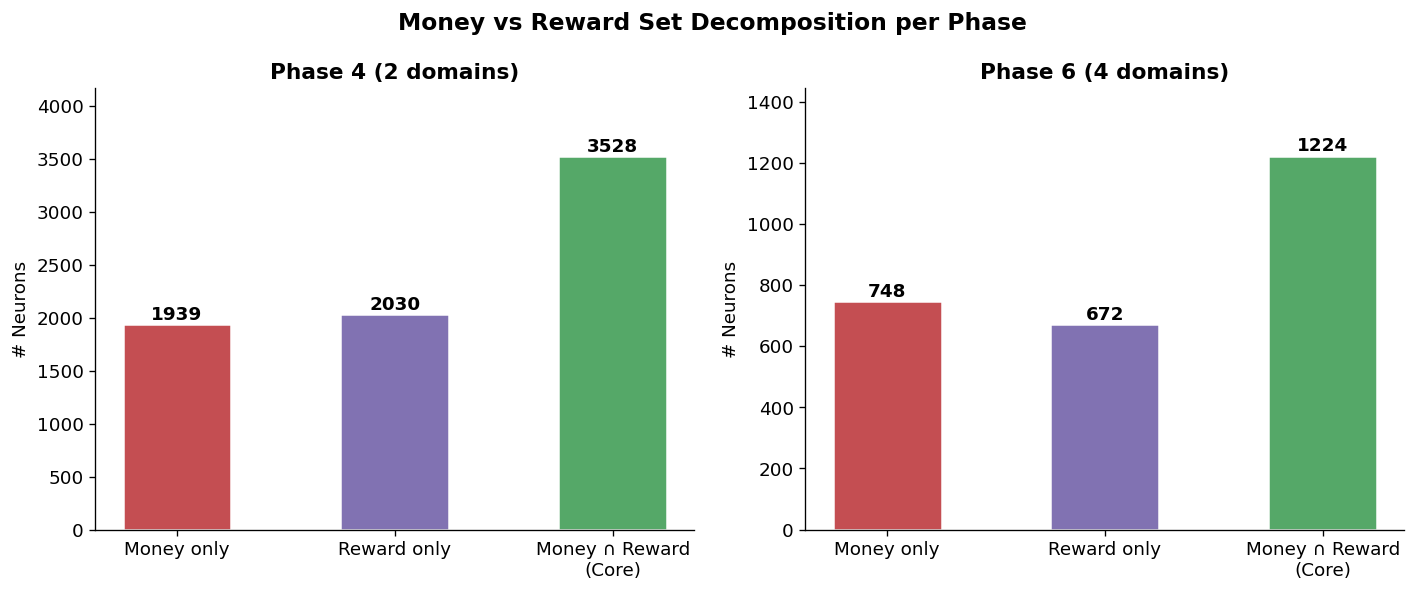

In [9]:
print("=" * 60)
print("CROSS-SET OVERLAP")
print("=" * 60)

for phase in ['p4', 'p6']:
    money_s  = data['money'][phase]
    reward_s = data['reward'][phase]
    core_s   = data['core'][phase]
    mon_rew  = money_s & reward_s
    print(f"\nPhase {phase[-1]}:")
    print(f"  Money ∩ Reward          : {len(mon_rew):>5}")
    print(f"  Money ∩ Reward == Core? : {mon_rew == core_s}  "
          f"(Core has {len(core_s)}, intersection has {len(mon_rew)})")
    print(f"  Money only (not reward) : {len(money_s - reward_s):>5}")
    print(f"  Reward only (not money) : {len(reward_s - money_s):>5}")

# Venn-style: 3 circles as grouped bar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, phase, label in zip(axes, ['p4', 'p6'], ['Phase 4 (2 domains)', 'Phase 6 (4 domains)']):
    money_s  = data['money'][phase]
    reward_s = data['reward'][phase]
    core_s   = data['core'][phase]
    categories = ['Money only', 'Reward only', 'Money ∩ Reward\n(Core)']
    counts     = [
        len(money_s - reward_s),
        len(reward_s - money_s),
        len(core_s),
    ]
    bars = ax.bar(categories, counts,
                  color=[COLORS['only_p4'], COLORS['only_p6'], COLORS['shared']],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(cnt), ha='center', va='bottom', fontweight='bold')
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_ylabel('# Neurons')
    ax.set_ylim(0, max(counts) * 1.18)

plt.suptitle('Money vs Reward Set Decomposition per Phase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_cross_set.png', bbox_inches='tight')
plt.show()

## 8. Stability Analysis — Which Layers Are Most Stable Across Phases?

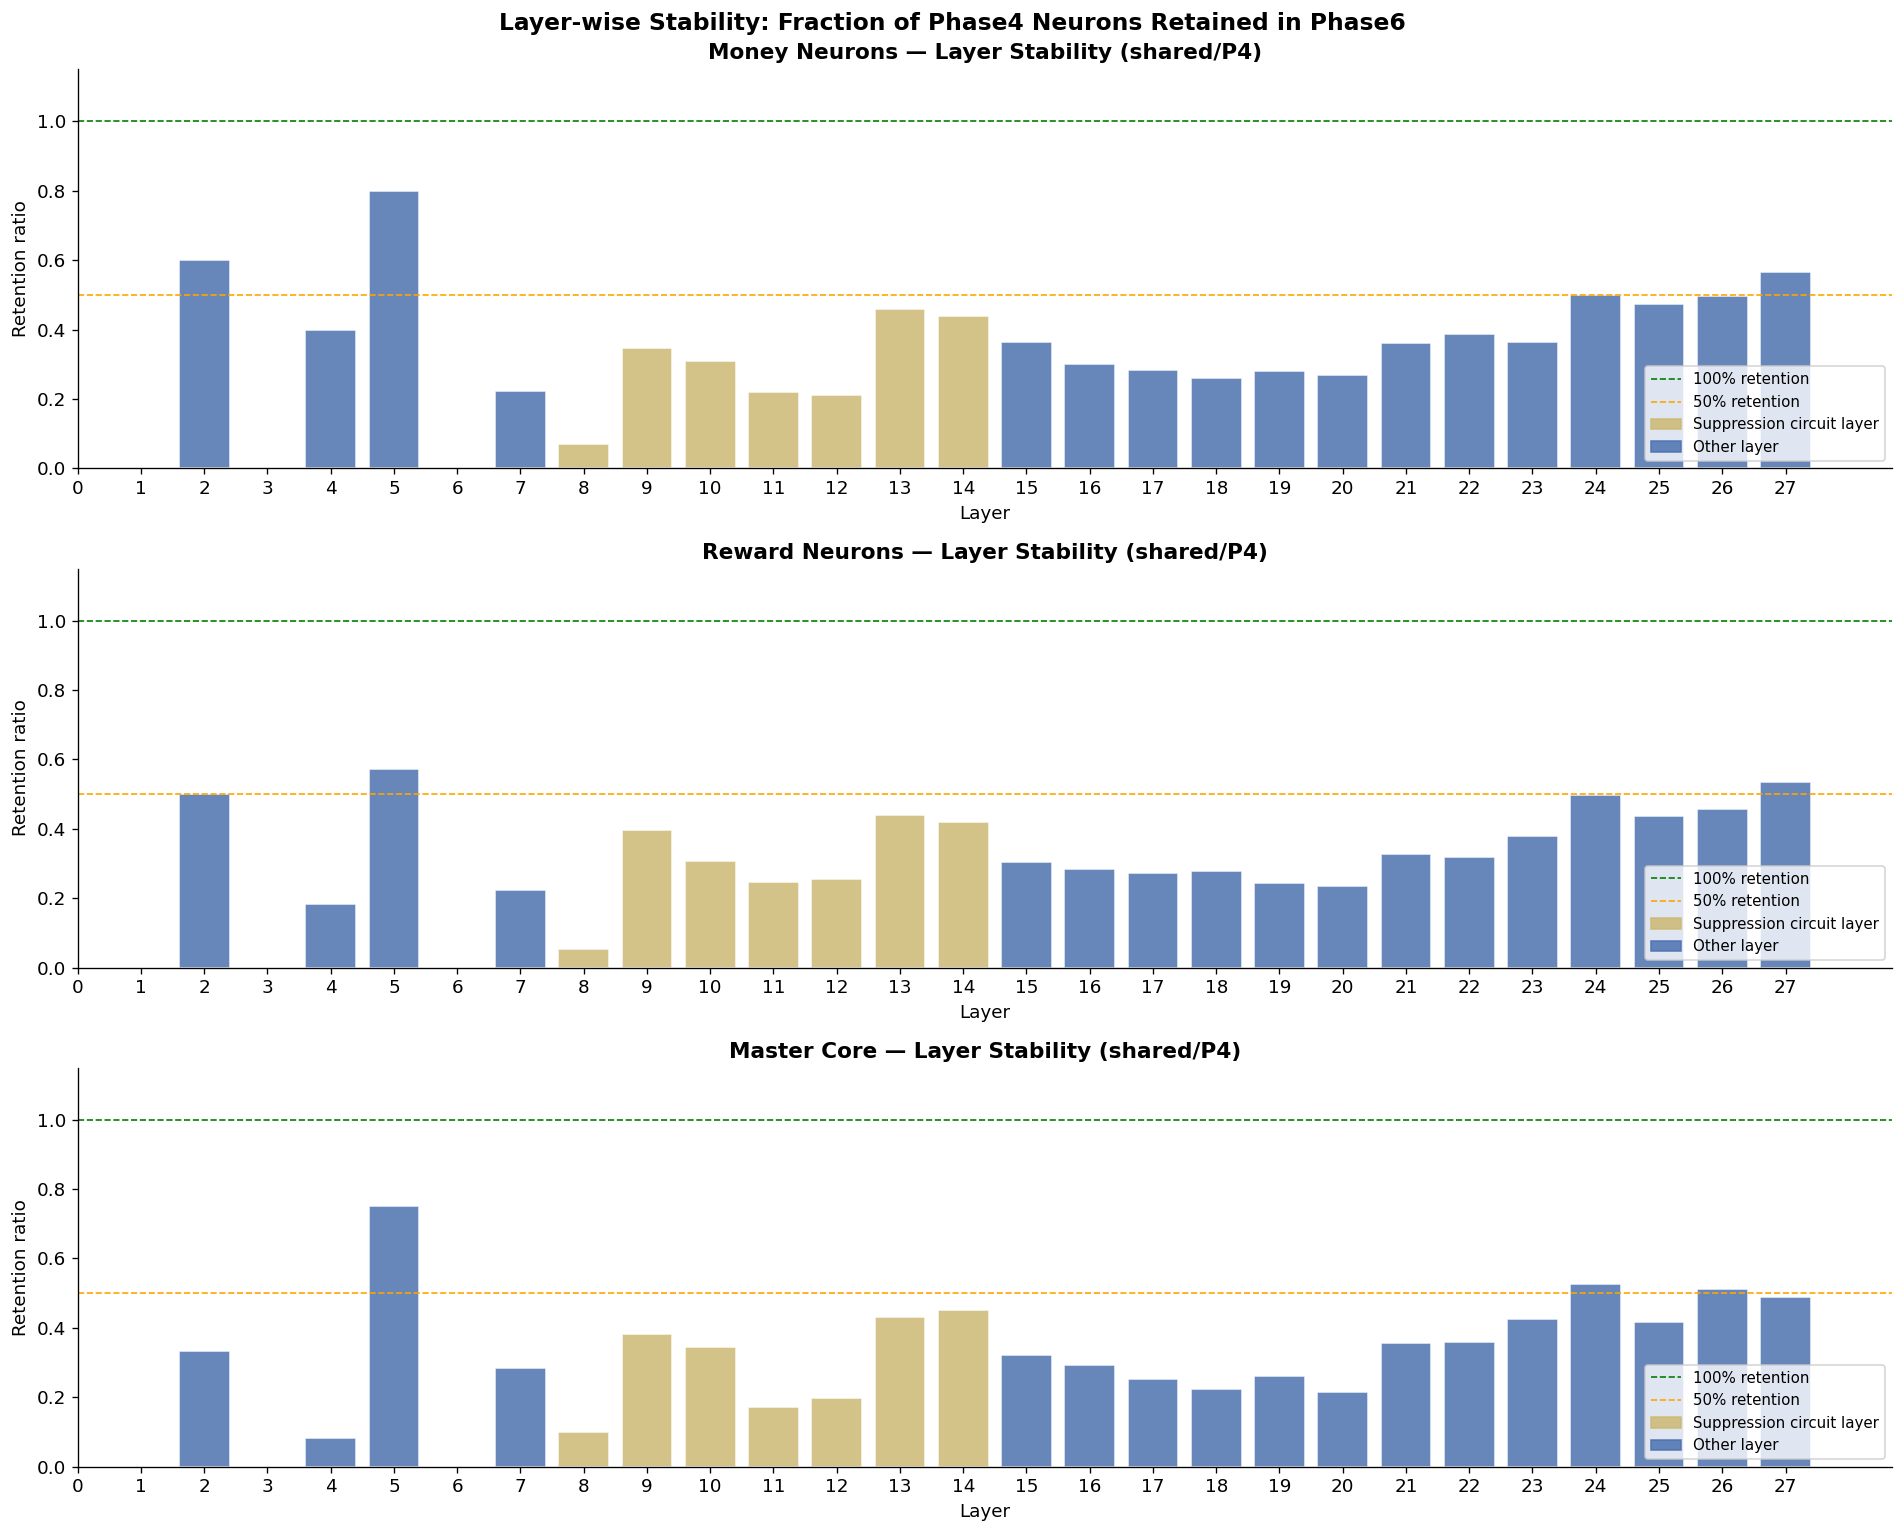

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))

for ax, (key, title) in zip(axes, titles.items()):
    d = data[key]
    c_p4     = layer_counts(d['p4']).astype(float)
    c_shared = layer_counts(d['shared']).astype(float)

    # Stability = shared / p4 per layer (NaN where p4=0)
    stability = np.where(c_p4 > 0, c_shared / c_p4, np.nan)

    colors = [COLORS['circuit'] if l in SUPPRESSION_LAYERS else COLORS['p4'] for l in layers]
    bars = ax.bar(layers, stability, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(1.0, color='green',  linewidth=1, linestyle='--', label='100% retention')
    ax.axhline(0.5, color='orange', linewidth=1, linestyle='--', label='50% retention')

    ax.set_ylim(0, 1.15)
    ax.set_title(f"{title} — Layer Stability (shared/P4)", fontweight='bold', fontsize=13)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Retention ratio')
    ax.set_xticks(layers)

    from matplotlib.patches import Patch
    patches = [
        Patch(color=COLORS['circuit'], alpha=0.85, label='Suppression circuit layer'),
        Patch(color=COLORS['p4'],      alpha=0.85, label='Other layer'),
    ]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + patches, labels + [p.get_label() for p in patches], fontsize=9, loc='lower right')

plt.suptitle('Layer-wise Stability: Fraction of Phase4 Neurons Retained in Phase6', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_stability.png', bbox_inches='tight')
plt.show()

## 9. Full Numerical Summary

In [11]:
print("=" * 70)
print("FULL NUMERICAL SUMMARY")
print("=" * 70)

for key in FILES:
    d = data[key]
    print(f"\n{'─'*70}")
    print(f"  {key.upper()}")
    print(f"{'─'*70}")
    print(f"  Phase4 total : {len(d['p4'])}")
    print(f"  Phase6 total : {len(d['p6'])}")
    print(f"  Shared       : {len(d['shared'])}  "
          f"({len(d['shared'])/len(d['p4'])*100:.1f}% of P4, "
          f"{len(d['shared'])/len(d['p6'])*100:.1f}% of P6)")
    print(f"  P4-only      : {len(d['only_p4'])}  (dropped when adding new domains)")
    print(f"  P6-only      : {len(d['only_p6'])}  (new, not in P4)")

    print(f"\n  Per-layer breakdown:")
    hdr = f"  {'Layer':<7} {'P4':>6} {'P6':>6} {'Shared':>8} {'P4-only':>8} {'P6-only':>8} {'Stability':>10}"
    print(hdr)
    print('  ' + '-' * (len(hdr)-2))
    for l in range(NUM_LAYERS):
        p4_l  = sum(1 for ll,_ in d['p4']      if ll == l)
        p6_l  = sum(1 for ll,_ in d['p6']      if ll == l)
        sh_l  = sum(1 for ll,_ in d['shared']  if ll == l)
        op4_l = sum(1 for ll,_ in d['only_p4'] if ll == l)
        op6_l = sum(1 for ll,_ in d['only_p6'] if ll == l)
        stab  = f"{sh_l/p4_l*100:.0f}%" if p4_l > 0 else '—'
        circ  = ' ◀ circuit' if l in SUPPRESSION_LAYERS else ''
        if any([p4_l, p6_l, sh_l, op4_l, op6_l]):
            print(f"  L{l:<6} {p4_l:>6} {p6_l:>6} {sh_l:>8} {op4_l:>8} {op6_l:>8} {stab:>10}{circ}")

print(f"\n{'='}" * 70)

FULL NUMERICAL SUMMARY

──────────────────────────────────────────────────────────────────────
  MONEY
──────────────────────────────────────────────────────────────────────
  Phase4 total : 5467
  Phase6 total : 1972
  Shared       : 1972  (36.1% of P4, 100.0% of P6)
  P4-only      : 3495  (dropped when adding new domains)
  P6-only      : 0  (new, not in P4)

  Per-layer breakdown:
  Layer       P4     P6   Shared  P4-only  P6-only  Stability
  -----------------------------------------------------------
  L2           5      3        3        2        0        60%
  L3           2      0        0        2        0         0%
  L4          15      6        6        9        0        40%
  L5           5      4        4        1        0        80%
  L6           6      0        0        6        0         0%
  L7          18      4        4       14        0        22%
  L8          42      3        3       39        0         7% ◀ circuit
  L9         153     53       53      100    

## 10. Export Shared & Phase6-Only Core Neurons

In [12]:
d = data['core']

# Shared core — stable across both phases
shared_core_df = pd.DataFrame(sorted(d['shared']), columns=['layer', 'neuron'])
shared_core_df.to_csv('core_shared_p4_p6.csv', index=False)
print(f"Saved core_shared_p4_p6.csv  ({len(shared_core_df)} neurons)")

# Phase6-only core — new neurons from expanded domains
only_p6_core_df = pd.DataFrame(sorted(d['only_p6']), columns=['layer', 'neuron'])
only_p6_core_df.to_csv('core_only_p6.csv', index=False)
print(f"Saved core_only_p6.csv       ({len(only_p6_core_df)} neurons)")

# Phase4-only core — dropped neurons
only_p4_core_df = pd.DataFrame(sorted(d['only_p4']), columns=['layer', 'neuron'])
only_p4_core_df.to_csv('core_only_p4.csv', index=False)
print(f"Saved core_only_p4.csv       ({len(only_p4_core_df)} neurons)")

# Suppression circuit subset of shared core
shared_circuit_df = shared_core_df[shared_core_df['layer'].isin(SUPPRESSION_LAYERS)]
shared_circuit_df.to_csv('core_shared_circuit_L8_14.csv', index=False)
print(f"Saved core_shared_circuit_L8_14.csv ({len(shared_circuit_df)} neurons in L8–14)")

display(shared_core_df.groupby('layer').size().rename('shared_core_count').to_frame())

Saved core_shared_p4_p6.csv  (1224 neurons)
Saved core_only_p6.csv       (0 neurons)
Saved core_only_p4.csv       (2304 neurons)
Saved core_shared_circuit_L8_14.csv (489 neurons in L8–14)


,shared_core_count
layer,
2,1
4,1
5,3
7,2
8,2
9,41
10,77
11,28
12,28
